# MERMAID EDA
Exploratory analysis of the S3-hosted copy of the MERMAID dataset produced by download_raw_data_and_add_to_s3.py.

All inputs are read from S3 (s3://dev-datamermaid-sm-sources/external_validation_datasets/catlin_seaview/) — no local files needed.


UPDATEEE

In [1]:
import json

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

from mermaidseg.datasets import MermaidDataset

/home/sagemaker-user/mermaid-segmentation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
BUCKET = "coral-reef-training"
PREFIX = "mermaid"

s3 = boto3.client("s3")

parquet_uri = f"s3://{BUCKET}/{PREFIX}/mermaid_confirmed_annotations.parquet"
df_meta = pd.read_parquet(parquet_uri)
df_meta["source_label_name"] = df_meta["benthic_attribute_name"]

In [21]:
df_meta.shape, df_meta["image_id"].nunique()

((339925, 13), 13597)

In [18]:
regions_df = (
    df_meta.groupby("region_name", sort=True)
    .agg(
        num_images=("image_id", "nunique"),
        num_annotations=("image_id", "size"),
        num_label_classes=("source_label_name", "nunique"),
    )
)

regions_df.loc["TOTAL"] = {
    "num_images": df_meta["image_id"].nunique(),
    "num_annotations": len(df_meta),
    "num_label_classes": df_meta["source_label_name"].nunique(),
}
regions_df

,num_images,num_annotations,num_label_classes
region_name,,,
Central Indo-Pacific,8779,219475,169
Tropical Atlantic,133,3325,54
Western Indo-Pacific,4685,117125,146
TOTAL,13597,339925,236


## Instantiate the dataset

In [11]:
dataset = MermaidDataset(
    padding=7,
)
print(f"Dataset length: {len(dataset)}")
print(f"Num source classes (incl. background): {dataset.num_source_classes}")
dataset.df_annotations.head()

Dataset length: 13597
Num source classes (incl. background): 237


,id,image_id,point_id,row,col,benthic_attribute_id,source_label_name,growth_form_id,growth_form_name,updated_on,region_id,region_name
0,adf9f72c-f498-454b-b4c2-d3cb6a2d1c5f,00059a47-03b8-47f3-adf6-3ab5616922cf,44044125-e1b8-4580-8531-acaf18a66935,457,467,30a987e9-b420-4db6-a83a-a1f7cabd14fb,Soft coral,None,None,2025-08-26 14:55:15.009823+00:00,1d31d9ea-e78d-438b-8667-0d63d1aba257,Western Indo-Pacific
1,0e97b960-cc38-49ed-91c6-f760f1eff354,00059a47-03b8-47f3-adf6-3ab5616922cf,e8c950a2-c37f-4f5e-8797-3f2d244257b6,457,934,b76bca12-884b-4404-bb9f-97d505b0fe58,Sand,None,None,2025-08-26 14:55:15.039272+00:00,1d31d9ea-e78d-438b-8667-0d63d1aba257,Western Indo-Pacific
2,1823ca56-edac-459e-b009-46c390f64afe,00059a47-03b8-47f3-adf6-3ab5616922cf,766bd109-c9f7-4489-8215-f2a46ffd9419,457,1401,d9086647-3a82-4634-97bc-6e10347af39b,Bare substrate,None,None,2025-08-26 14:55:15.085659+00:00,1d31d9ea-e78d-438b-8667-0d63d1aba257,Western Indo-Pacific
3,dc9d3b2d-b9f9-4a46-a208-790b5c3b2ec3,00059a47-03b8-47f3-adf6-3ab5616922cf,6aaaea05-f005-4e3e-a9bf-d6702e0b7736,457,1868,ed2332ed-0762-45fb-87a3-d315e218faf1,Rubble,None,None,2025-08-26 14:55:15.133907+00:00,1d31d9ea-e78d-438b-8667-0d63d1aba257,Western Indo-Pacific
4,9bde5850-bb38-4ca3-88b3-43799f53f0ea,00059a47-03b8-47f3-adf6-3ab5616922cf,bed04244-e299-4eec-b9b7-05e15dbf5a75,457,2335,ed2332ed-0762-45fb-87a3-d315e218faf1,Rubble,None,None,2025-08-26 14:55:15.181096+00:00,1d31d9ea-e78d-438b-8667-0d63d1aba257,Western Indo-Pacific


## Sample image + sparse annotations per region

In [12]:
def build_palette(label_names: list[str], seed: int = 1337) -> dict[str, list[int]]:
    """Build a deterministic RGB palette keyed by label name.

    Mirrors ``build_palette`` in ``catlin_seaview.ipynb``.
    """
    rng = np.random.default_rng(seed)
    colors: dict[str, list[int]] = {"unlabeled": [0, 0, 0]}
    for name in label_names:
        colors[name] = [int(x) for x in rng.integers(0, 256, size=3)]
    return colors

In [13]:
label_names = sorted(dataset.df_annotations["source_label_name"].unique().tolist())
colors = build_palette(label_names)

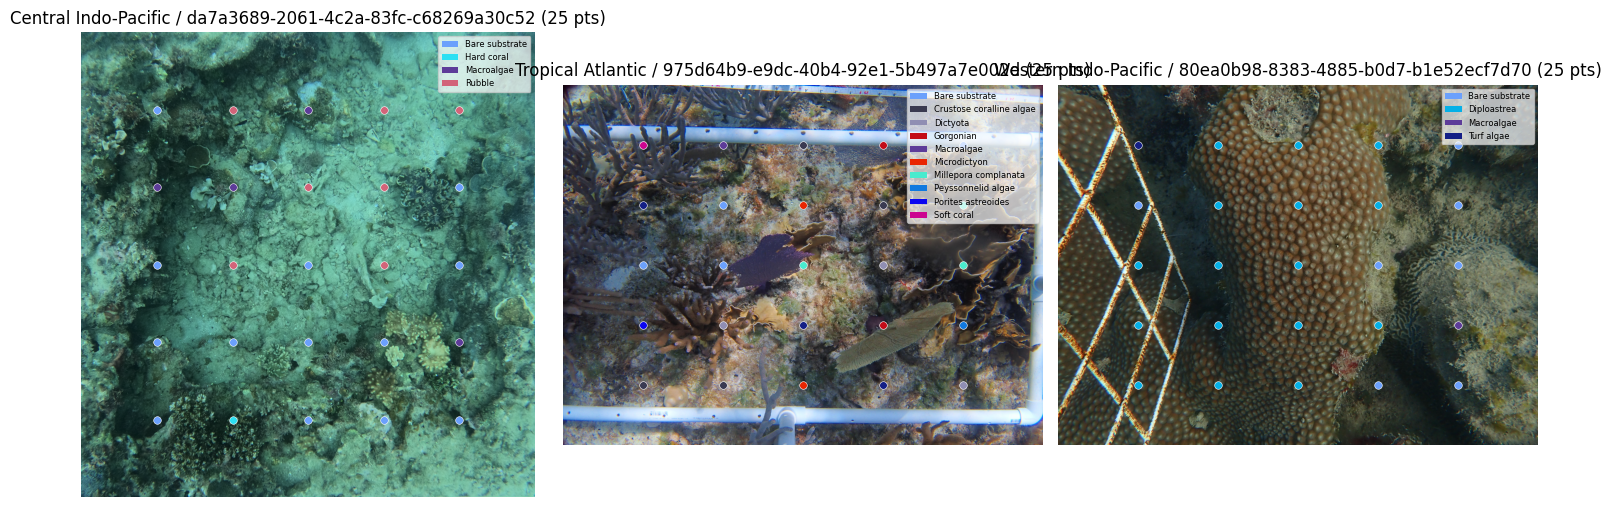

In [15]:
regions = sorted(dataset.df_images["region_name"].unique())
n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)

rng = np.random.default_rng(0)
for ax, region in zip(axes.ravel(), regions, strict=False):
    region_rows = dataset.df_images.index[dataset.df_images["region_name"] == region].to_numpy()
    if len(region_rows) == 0:
        ax.axis("off")
        ax.set_title(f"{region}: no images")
        continue
    idx = int(rng.choice(region_rows))
    image_id = dataset.df_images.loc[idx, "image_id"]
    image = dataset.read_image(image_id=image_id, region=region)

    anns = dataset.df_annotations.loc[
        (dataset.df_annotations["image_id"] == image_id)
        & (dataset.df_annotations["region_name"] == region),
        ["row", "col", "source_label_name"],
    ]

    ax.imshow(image)
    seen_labels = []
    for _, r in anns.iterrows():
        rgb = colors.get(r["source_label_name"], [255, 0, 0])
        ax.scatter(
            r["col"],
            r["row"],
            color=np.array(rgb) / 255.0,
            s=30,
            edgecolors="white",
            linewidths=0.4,
        )
        seen_labels.append(r["source_label_name"])
    handles = [
        Patch(facecolor=np.array(colors.get(name, [255, 0, 0])) / 255.0, label=name)
        for name in sorted(set(seen_labels))[:10]
    ]
    ax.set_title(f"{region} / {image_id} ({len(anns)} pts)")
    ax.axis("off")
    if handles:
        ax.legend(handles=handles, loc="upper right", fontsize=6, framealpha=0.7)

for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Top-20 label classes per region

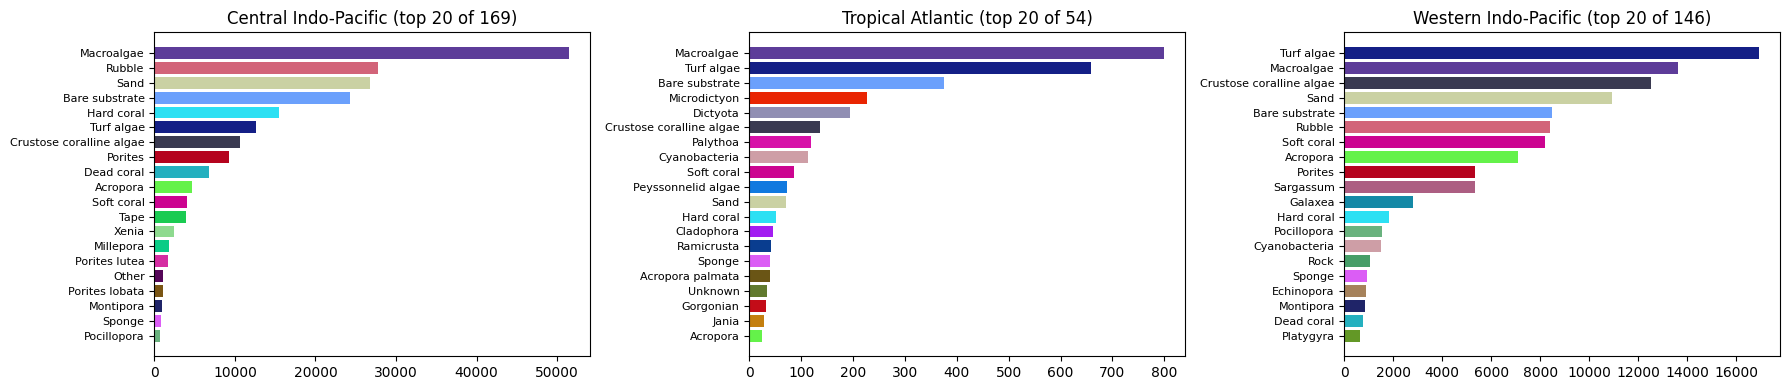

In [17]:
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)
for ax, region in zip(axes.ravel(), regions, strict=False):
    counts = (
        dataset.df_annotations.loc[dataset.df_annotations["region_name"] == region, "source_label_name"]
        .value_counts()
        .head(20)
    )
    if counts.empty:
        ax.set_title(f"{region}: no annotations")
        ax.axis("off")
        continue
    bar_colors = [np.array(colors.get(name, [128, 128, 128])) / 255.0 for name in counts.index]
    ax.barh(range(len(counts)), counts.to_numpy()[::-1], color=bar_colors[::-1])
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels(counts.index[::-1], fontsize=8)
    region_mask = dataset.df_annotations["region_name"] == region
    n_unique = dataset.df_annotations.loc[region_mask, "source_label_name"].nunique()
    ax.set_title(f"{region} (top 20 of {n_unique})")
for ax in axes.ravel()[len(regions) :]:
    ax.axis("off")
plt.tight_layout()
plt.show()